In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1611s 9us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training pixel range:", x_train.min(), "to", x_train.max())
print("Testing pixel range:", x_test.min(), "to", x_test.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


In [ ]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training labels: (50000, 10)
Testing labels: (10000, 10)


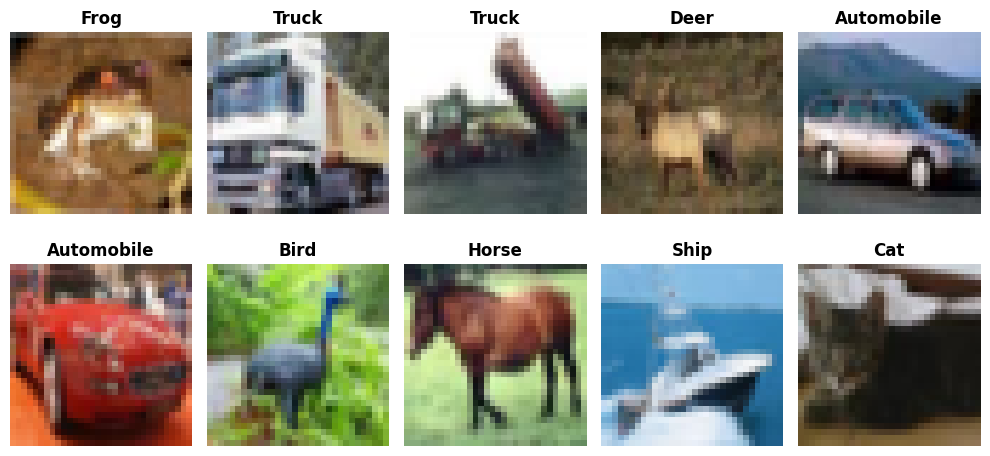

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(
        class_names[np.argmax(y_train[i])],
        fontweight="bold"
    )
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "01_sample_cifar10_images.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Task 2 - Prepare images for VGG16

BATCH_SIZE = 32

train_images = x_train[:40000]
train_labels = y_train[:40000]

val_images = x_train[40000:]
val_labels = y_train[40000:]

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_images, train_labels)
)

train_ds = train_ds.shuffle(
    10000,
    seed=42
)

train_ds = train_ds.map(
    lambda image, label: (
        tf.image.resize(image, (224, 224)),
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)


val_ds = tf.data.Dataset.from_tensor_slices(
    (val_images, val_labels)
)

val_ds = val_ds.map(
    lambda image, label: (
        tf.image.resize(image, (224, 224)),
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
)

test_ds = test_ds.map(
    lambda image, label: (
        tf.image.resize(image, (224, 224)),
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("Training samples:", len(train_images))
print("Validation samples:", len(val_images))
print("Testing samples:", len(x_test))

Training samples: 40000
Validation samples: 10000
Testing samples: 10000


In [ ]:
# Load pretrained VGG16

from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("VGG16 loaded successfully.")

VGG16 loaded successfully.


In [ ]:
# Add CIFAR-10 classifier

model = tf.keras.Sequential([
    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Compile VGG16

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Train VGG16

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

training_time = time.time() - start_time

print(
    f"Training Time: {training_time:.2f} seconds"
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 100s 70ms/step - accuracy: 0.4336 - loss: 1.6221 - val_accuracy: 0.5168 - val_loss: 1.3890
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.5508 - loss: 1.2926 - val_accuracy: 0.5651 - val_loss: 1.2365
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.5861 - loss: 1.1919 - val_accuracy: 0.5932 - val_loss: 1.1535
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.6040 - loss: 1.1346 - val_accuracy: 0.5889 - val_loss: 1.1518
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.6170 - loss: 1.0947 - val_accuracy: 0.6191 - val_loss: 1.0878
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - accuracy: 0.6294 - loss: 1.0657 - val_accuracy: 0.6181 - val_loss: 1.0947
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.6386 - loss: 1.0423 - val_accuracy: 0.6395 - val_loss: 1.0318
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.6410 

In [ ]:
# Test VGG16 Before Fine-Tuning

test_loss_before, test_accuracy_before = model.evaluate(
    test_ds,
    verbose=1
)

predictions_before = model.predict(
    test_ds,
    verbose=1
)

all_preds_before = np.argmax(
    predictions_before,
    axis=1
)

all_labels = np.argmax(
    y_test,
    axis=1
)

precision_before = precision_score(
    all_labels,
    all_preds_before,
    average="macro",
    zero_division=0
)

recall_before = recall_score(
    all_labels,
    all_preds_before,
    average="macro",
    zero_division=0
)

f1_before = f1_score(
    all_labels,
    all_preds_before,
    average="macro",
    zero_division=0
)

print("\nVGG16 BEFORE Fine-Tuning")
print(f"Test Accuracy      : {test_accuracy_before:.4f}")
print(f"Precision (macro)  : {precision_before:.4f}")
print(f"Recall (macro)     : {recall_before:.4f}")
print(f"F1-score (macro)   : {f1_before:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.6544 - loss: 1.0049
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step

VGG16 BEFORE Fine-Tuning
Test Accuracy      : 0.6544
Precision (macro)  : 0.6545
Recall (macro)     : 0.6544
F1-score (macro)   : 0.6507


In [ ]:
print(
    "\nClassification Report - BEFORE Fine-Tuning\n"
)

print(
    classification_report(
        all_labels,
        all_preds_before,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


Classification Report - BEFORE Fine-Tuning

              precision    recall  f1-score   support

    Airplane     0.7775    0.6850    0.7283      1000
  Automobile     0.6844    0.8220    0.7469      1000
        Bird     0.6516    0.4900    0.5594      1000
         Cat     0.5167    0.4020    0.4522      1000
        Deer     0.6200    0.5840    0.6014      1000
         Dog     0.5244    0.6240    0.5699      1000
        Frog     0.6257    0.7120    0.6660      1000
       Horse     0.6667    0.6940    0.6801      1000
        Ship     0.7654    0.7440    0.7546      1000
       Truck     0.7122    0.7870    0.7477      1000

    accuracy                         0.6544     10000
   macro avg     0.6545    0.6544    0.6507     10000
weighted avg     0.6545    0.6544    0.6507     10000



In [ ]:
import seaborn as sns

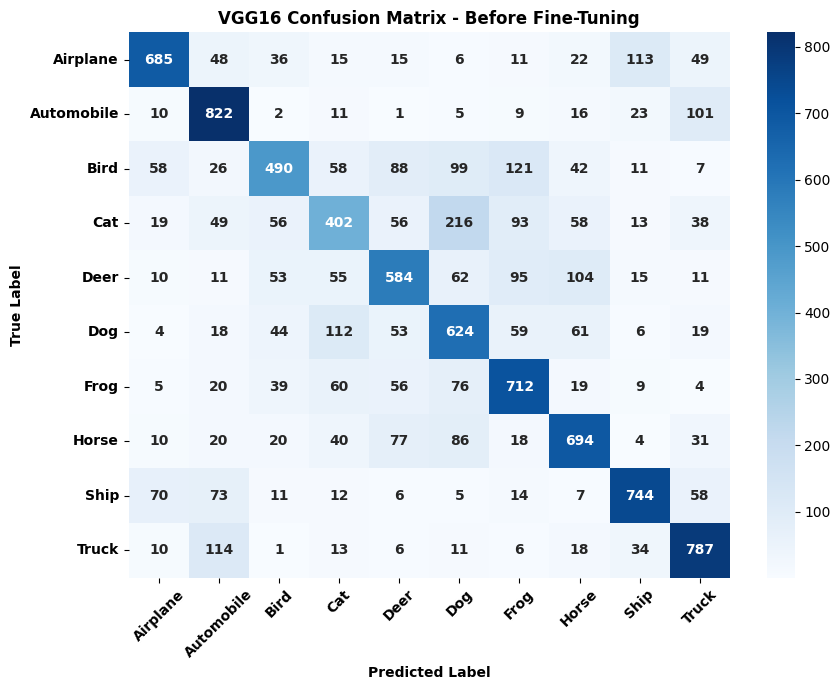

In [ ]:
cm_before = confusion_matrix(
    all_labels,
    all_preds_before
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_before,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"weight": "bold"}
)

plt.xlabel(
    "Predicted Label",
    fontweight="bold"
)

plt.ylabel(
    "True Label",
    fontweight="bold"
)

plt.title(
    "VGG16 Confusion Matrix - Before Fine-Tuning",
    fontweight="bold"
)

plt.xticks(
    fontweight="bold",
    rotation=45
)

plt.yticks(
    fontweight="bold",
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "sample_data/8_confusion_matrix_before_finetuning.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Fine-Tuning VGG16

base_model.trainable = True

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

print("Trainable layers:")

for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

Trainable layers:
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
start_time = time.time()

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

fine_tune_time = time.time() - start_time

print(
    f"Fine-Tuning Time: {fine_tune_time:.2f} seconds"
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 103s 75ms/step - accuracy: 0.6623 - loss: 1.0425 - val_accuracy: 0.7258 - val_loss: 0.7668
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 132s 72ms/step - accuracy: 0.8027 - loss: 0.5609 - val_accuracy: 0.8149 - val_loss: 0.5340
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 90s 72ms/step - accuracy: 0.8612 - loss: 0.3967 - val_accuracy: 0.8309 - val_loss: 0.5017
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 72ms/step - accuracy: 0.9008 - loss: 0.2809 - val_accuracy: 0.8375 - val_loss: 0.4945
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 90s 72ms/step - accuracy: 0.9306 - loss: 0.1999 - val_accuracy: 0.8290 - val_loss: 0.6058
Fine-Tuning Time: 556.56 seconds


In [ ]:
# Test VGG16 After Fine-Tuning

test_loss_after, test_accuracy_after = model.evaluate(
    test_ds,
    verbose=1
)

predictions_after = model.predict(
    test_ds,
    verbose=1
)

all_preds_after = np.argmax(
    predictions_after,
    axis=1
)

precision_after = precision_score(
    all_labels,
    all_preds_after,
    average="macro",
    zero_division=0
)

recall_after = recall_score(
    all_labels,
    all_preds_after,
    average="macro",
    zero_division=0
)

f1_after = f1_score(
    all_labels,
    all_preds_after,
    average="macro",
    zero_division=0
)

print("\nVGG16 AFTER Fine-Tuning")
print(f"Test Accuracy      : {test_accuracy_after:.4f}")
print(f"Precision (macro)  : {precision_after:.4f}")
print(f"Recall (macro)     : {recall_after:.4f}")
print(f"F1-score (macro)   : {f1_after:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8298 - loss: 0.6092
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 66ms/step

VGG16 AFTER Fine-Tuning
Test Accuracy      : 0.8298
Precision (macro)  : 0.8404
Recall (macro)     : 0.8298
F1-score (macro)   : 0.8297


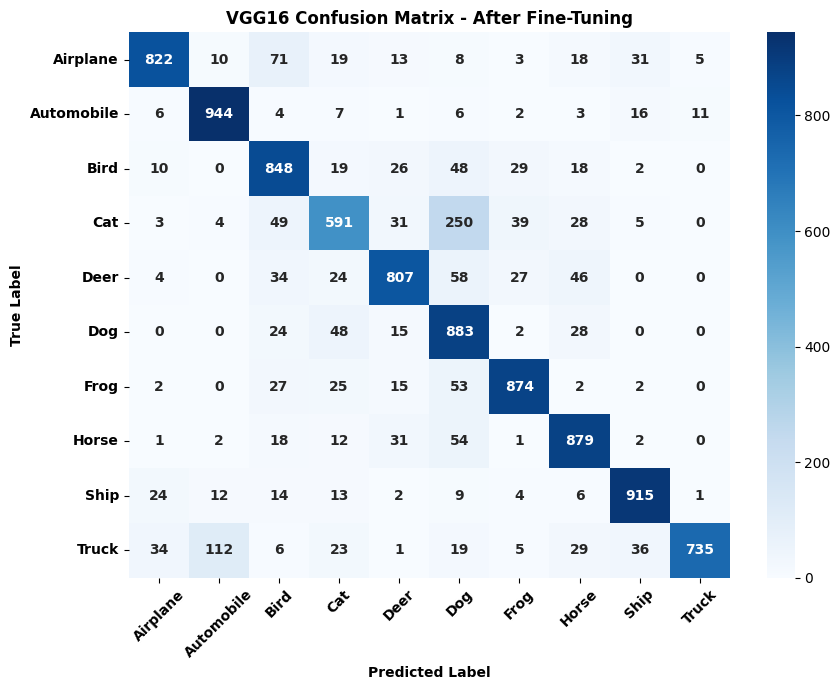

In [ ]:
cm_after = confusion_matrix(
    all_labels,
    all_preds_after
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_after,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"weight": "bold"}
)

plt.xlabel(
    "Predicted Label",
    fontweight="bold"
)

plt.ylabel(
    "True Label",
    fontweight="bold"
)

plt.title(
    "VGG16 Confusion Matrix - After Fine-Tuning",
    fontweight="bold"
)

plt.xticks(
    fontweight="bold",
    rotation=45
)

plt.yticks(
    fontweight="bold",
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "sample_data/9_confusion_matrix_after_finetuning.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

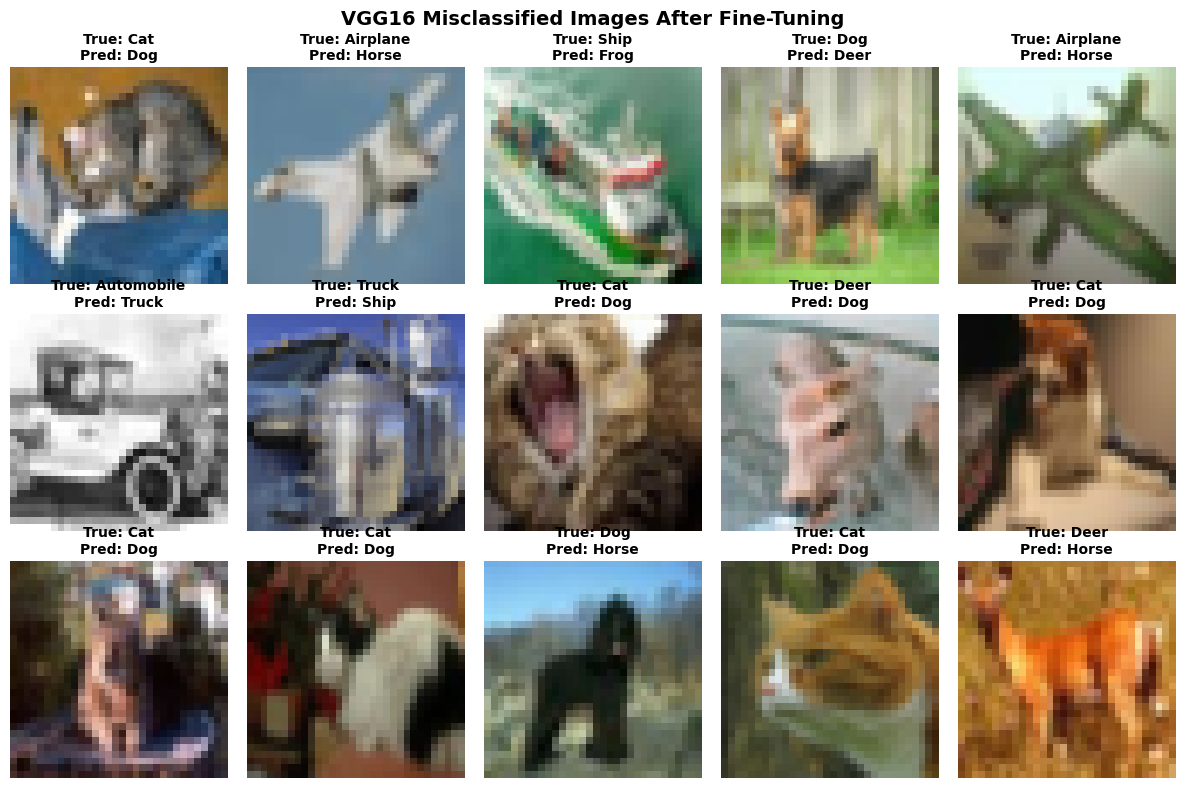

Total misclassified images: 1702


In [ ]:
# VGG16 Misclassified Images - After Fine-Tuning

misclassified = np.where(
    all_labels != all_preds_after
)[0]

plt.figure(figsize=(12, 8))

for i, index in enumerate(misclassified[:15]):

    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[index])

    plt.title(
        f"True: {class_names[all_labels[index]]}\n"
        f"Pred: {class_names[all_preds_after[index]]}",
        fontweight="bold",
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "VGG16 Misclassified Images After Fine-Tuning",
    fontweight="bold",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "sample_data/vgg16_misclassified_images.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Total misclassified images: {len(misclassified)}"
)

In [ ]:
comparison = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Before Fine-Tuning": [
        test_accuracy_before,
        precision_before,
        recall_before,
        f1_before
    ],

    "After Fine-Tuning": [
        test_accuracy_after,
        precision_after,
        recall_after,
        f1_after
    ]
})

comparison["Improvement"] = (
    comparison["After Fine-Tuning"]
    - comparison["Before Fine-Tuning"]
)

display(comparison)

,Metric,Before Fine-Tuning,After Fine-Tuning,Improvement
0,Test Accuracy,0.654400,0.829800,0.175400
1,Precision,0.654456,0.840438,0.185982
2,Recall,0.654400,0.829800,0.175400
3,F1-score,0.650654,0.829709,0.179055


In [ ]:
# Combine training histories

train_accuracy = (
    history.history["accuracy"] +
    fine_tune_history.history["accuracy"]
)

val_accuracy = (
    history.history["val_accuracy"] +
    fine_tune_history.history["val_accuracy"]
)

train_loss = (
    history.history["loss"] +
    fine_tune_history.history["loss"]
)

val_loss = (
    history.history["val_loss"] +
    fine_tune_history.history["val_loss"]
)

epochs = range(1, len(train_accuracy) + 1)

print("Total epochs:", len(train_accuracy))

Total epochs: 15


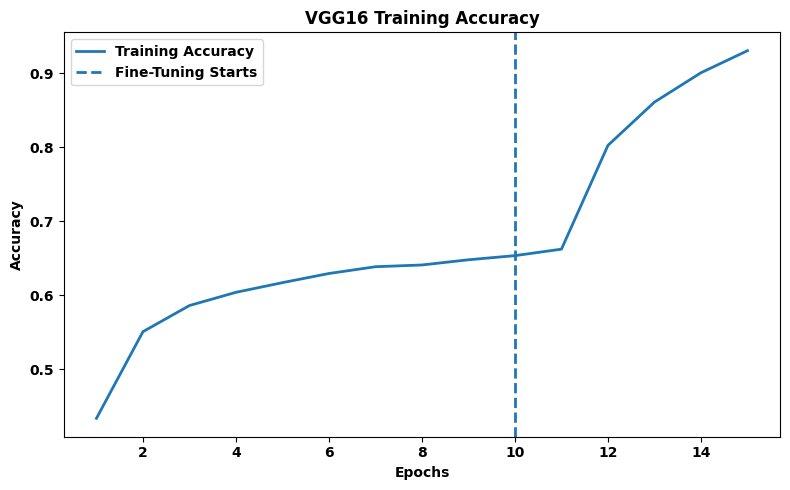

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracy,
    label="Training Accuracy",
    linewidth=2
)

plt.axvline(
    x=len(history.history["accuracy"]),
    linestyle="--",
    label="Fine-Tuning Starts",
    linewidth=2
)

plt.xlabel(
    "Epochs",
    fontweight="bold"
)

plt.ylabel(
    "Accuracy",
    fontweight="bold"
)

plt.title(
    "VGG16 Training Accuracy",
    fontweight="bold"
)

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.legend(
    prop={"weight": "bold"}
)

plt.tight_layout()

plt.savefig(
    "sample_data/vgg16_training_accuracy.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

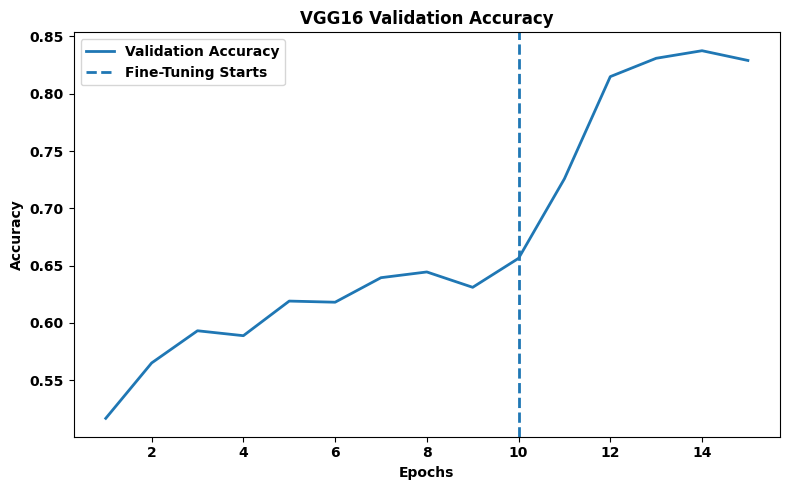

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    val_accuracy,
    label="Validation Accuracy",
    linewidth=2
)

plt.axvline(
    x=len(history.history["val_accuracy"]),
    linestyle="--",
    label="Fine-Tuning Starts",
    linewidth=2
)

plt.xlabel(
    "Epochs",
    fontweight="bold"
)

plt.ylabel(
    "Accuracy",
    fontweight="bold"
)

plt.title(
    "VGG16 Validation Accuracy",
    fontweight="bold"
)

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.legend(
    prop={"weight": "bold"}
)

plt.tight_layout()

plt.savefig(
    "sample_data/vgg16_validation_accuracy.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

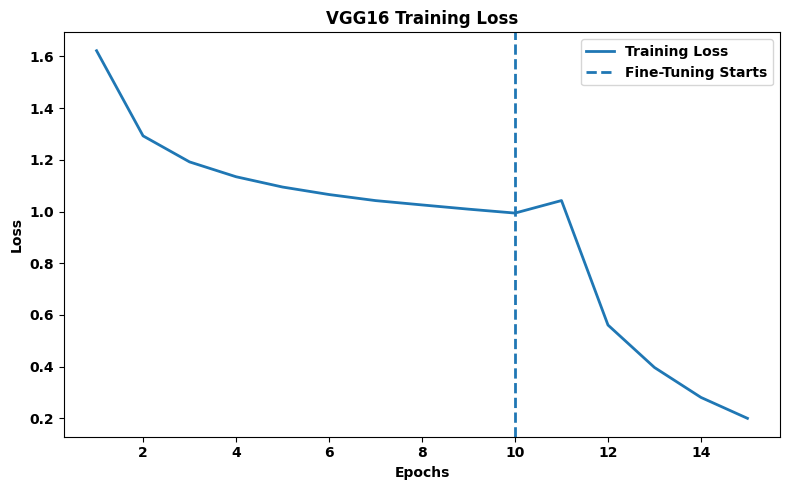

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    label="Training Loss",
    linewidth=2
)

plt.axvline(
    x=len(history.history["loss"]),
    linestyle="--",
    label="Fine-Tuning Starts",
    linewidth=2
)

plt.xlabel(
    "Epochs",
    fontweight="bold"
)

plt.ylabel(
    "Loss",
    fontweight="bold"
)

plt.title(
    "VGG16 Training Loss",
    fontweight="bold"
)

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.legend(
    prop={"weight": "bold"}
)

plt.tight_layout()

plt.savefig(
    "sample_data/vgg16_training_loss.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

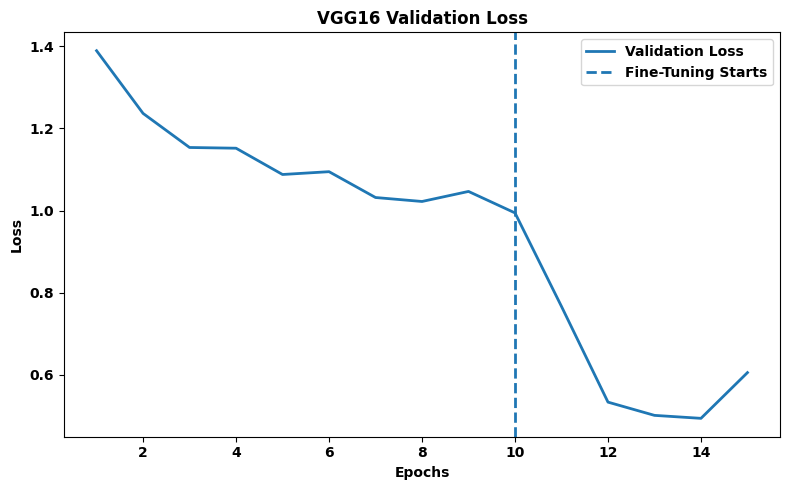

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    val_loss,
    label="Validation Loss",
    linewidth=2
)

plt.axvline(
    x=len(history.history["val_loss"]),
    linestyle="--",
    label="Fine-Tuning Starts",
    linewidth=2
)

plt.xlabel(
    "Epochs",
    fontweight="bold"
)

plt.ylabel(
    "Loss",
    fontweight="bold"
)

plt.title(
    "VGG16 Validation Loss",
    fontweight="bold"
)

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.legend(
    prop={"weight": "bold"}
)

plt.tight_layout()

plt.savefig(
    "sample_data/vgg16_validation_loss.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Hyperparameter Study - Small Subset

hp_train_images = x_train[:5000]
hp_train_labels = y_train[:5000]

hp_val_images = x_train[5000:6000]
hp_val_labels = y_train[5000:6000]

hp_train_ds = tf.data.Dataset.from_tensor_slices(
    (hp_train_images, hp_train_labels)
).batch(32)

hp_val_ds = tf.data.Dataset.from_tensor_slices(
    (hp_val_images, hp_val_labels)
).batch(32)

In [ ]:
# Create a frozen VGG16 model for hyperparameter study

def create_hp_model(
    learning_rate=0.001,
    optimizer_name="adam",
    dense_units=128
):

    base = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = False

    inputs = tf.keras.Input(
        shape=(32, 32, 3)
    )

    x = tf.keras.layers.Resizing(
        224,
        224
    )(inputs)

    x = base(x, training=False)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        dense_units,
        activation="relu"
    )(x)

    outputs = tf.keras.layers.Dense(
        10,
        activation="softmax"
    )(x)

    hp_model = tf.keras.Model(
        inputs,
        outputs
    )

    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    else:
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    hp_model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return hp_model

In [ ]:
# Hyperparameter configurations

hyperparameter_configs = [
    {
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 5,
        "optimizer": "adam",
        "dense_units": 128
    },
    {
        "learning_rate": 0.0001,
        "batch_size": 32,
        "epochs": 5,
        "optimizer": "adam",
        "dense_units": 128
    },
    {
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 5,
        "optimizer": "sgd",
        "dense_units": 128
    },
    {
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 5,
        "optimizer": "adam",
        "dense_units": 256
    }
]

In [ ]:
# Run Hyperparameter Study

hyperparameter_results = []

for i, config in enumerate(hyperparameter_configs):

    print(
        f"\nConfiguration {i + 1}/{len(hyperparameter_configs)}"
    )

    print(config)

    hp_model = create_hp_model(
        learning_rate=config["learning_rate"],
        optimizer_name=config["optimizer"],
        dense_units=config["dense_units"]
    )

    start_time = time.time()

    hp_history = hp_model.fit(
        hp_train_ds,
        validation_data=hp_val_ds,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        verbose=1
    )

    elapsed_time = time.time() - start_time

    best_val_accuracy = max(
        hp_history.history["val_accuracy"]
    )

    hyperparameter_results.append({
        **config,
        "Best Validation Accuracy": best_val_accuracy,
        "Training Time (seconds)": elapsed_time,
        "Parameters": hp_model.count_params()
    })

    print(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy:.4f}"
    )


Configuration 1/4
{'learning_rate': 0.001, 'batch_size': 32, 'epochs': 5, 'optimizer': 'adam', 'dense_units': 128}
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.2546 - loss: 2.1011 - val_accuracy: 0.3530 - val_loss: 1.8982
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.3842 - loss: 1.7949 - val_accuracy: 0.3960 - val_loss: 1.7074
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.4352 - loss: 1.6432 - val_accuracy: 0.4560 - val_loss: 1.5972
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.4688 - loss: 1.5524 - val_accuracy: 0.4740 - val_loss: 1.5342
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.4960 - loss: 1.4866 - val_accuracy: 0.5050 - val_loss: 1.4859
Best Validation Accuracy: 0.5050

Configuration 2/4
{'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 5, 'optimizer': 'adam', 'dense_units': 128}
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.1452 - loss: 2.3010 -

In [ ]:
# Hyperparameter Results

hyperparameter_df = pd.DataFrame(
    hyperparameter_results
)

display(hyperparameter_df)

hyperparameter_df.to_csv(
    "sample_data/vgg16_hyperparameter_study.csv",
    index=False
)

,learning_rate,batch_size,epochs,optimizer,dense_units,Best Validation Accuracy,Training Time (seconds),Parameters
0,0.0010,32,5,adam,128,0.505,61.719833,14781642
1,0.0001,32,5,adam,128,0.355,56.390533,14781642
2,0.0010,32,5,sgd,128,0.135,57.820408,14781642
3,0.0010,32,5,adam,256,0.505,56.620413,14848586


In [ ]:
# Best Configuration

best_result = hyperparameter_df.loc[
    hyperparameter_df["Best Validation Accuracy"].idxmax()
]

print("Best Configuration")
print("=" * 30)

for column, value in best_result.items():
    print(f"{column}: {value}")

Best Configuration
learning_rate: 0.001
batch_size: 32
epochs: 5
optimizer: adam
dense_units: 128
Best Validation Accuracy: 0.5049999952316284
Training Time (seconds): 61.71983313560486
Parameters: 14781642


In [ ]:
class LeNet5(tf.keras.Model):

    def __init__(self):
        super().__init__()

        self.conv1 = tf.keras.layers.Conv2D(
            6,
            kernel_size=5,
            activation="tanh"
        )

        self.pool1 = tf.keras.layers.AveragePooling2D(
            pool_size=2
        )

        self.conv2 = tf.keras.layers.Conv2D(
            16,
            kernel_size=5,
            activation="tanh"
        )

        self.pool2 = tf.keras.layers.AveragePooling2D(
            pool_size=2
        )

        self.flatten = tf.keras.layers.Flatten()

        self.fc1 = tf.keras.layers.Dense(
            120,
            activation="tanh"
        )

        self.fc2 = tf.keras.layers.Dense(
            84,
            activation="tanh"
        )

        self.output_layer = tf.keras.layers.Dense(
            10,
            activation="softmax"
        )

    def call(self, x):

        x = self.conv1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.pool2(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.fc2(x)

        return self.output_layer(x)

In [ ]:
lenet = LeNet5()

lenet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

lenet_history = lenet.fit(
    x_train[:40000],
    y_train[:40000],
    validation_data=(
        x_train[40000:],
        y_train[40000:]
    ),
    epochs=10,
    batch_size=32,
    verbose=1
)

lenet_time = time.time() - start_time

print(f"LeNet-5 Training Time: {lenet_time:.2f} seconds")

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.3609 - loss: 1.7949 - val_accuracy: 0.3932 - val_loss: 1.6880
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4433 - loss: 1.5674 - val_accuracy: 0.4563 - val_loss: 1.5096
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4868 - loss: 1.4355 - val_accuracy: 0.4851 - val_loss: 1.4423
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5205 - loss: 1.3541 - val_accuracy: 0.5119 - val_loss: 1.3791
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.5407 - loss: 1.2910 - val_accuracy: 0.5218 - val_loss: 1.3567
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5623 - loss: 1.2349 - val_accuracy: 0.5277 - val_loss: 1.3495
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5799 - loss: 1.1850 - val_accuracy: 0.5048 - val_loss: 1.4197
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5942 - loss: 1.1416 

In [ ]:
lenet_loss, lenet_accuracy = lenet.evaluate(
    x_test,
    y_test,
    verbose=1
)

lenet_predictions = lenet.predict(
    x_test,
    verbose=1
)

lenet_preds = np.argmax(
    lenet_predictions,
    axis=1
)

lenet_labels = np.argmax(
    y_test,
    axis=1
)

lenet_precision = precision_score(
    lenet_labels,
    lenet_preds,
    average="macro",
    zero_division=0
)

lenet_recall = recall_score(
    lenet_labels,
    lenet_preds,
    average="macro",
    zero_division=0
)

lenet_f1 = f1_score(
    lenet_labels,
    lenet_preds,
    average="macro",
    zero_division=0
)

print("\nLeNet-5 Results")
print(f"Test Accuracy : {lenet_accuracy:.4f}")
print(f"Precision     : {lenet_precision:.4f}")
print(f"Recall        : {lenet_recall:.4f}")
print(f"F1-score      : {lenet_f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        lenet_labels,
        lenet_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5377 - loss: 1.3351
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

LeNet-5 Results
Test Accuracy : 0.5377
Precision     : 0.5350
Recall        : 0.5377
F1-score      : 0.5344

Classification Report

              precision    recall  f1-score   support

    Airplane     0.5482    0.6030    0.5743      1000
  Automobile     0.6823    0.6400    0.6605      1000
        Bird     0.4265    0.4640    0.4444      1000
         Cat     0.4009    0.2630    0.3176      1000
        Deer     0.4653    0.4820    0.4735      1000
         Dog     0.4461    0.4760    0.4606      1000
        Frog     0.5798    0.6210    0.5997      1000
       Horse     0.6029    0.5770    0.5897      1000
        Ship     0.6199    0.6540    0.6365      1000
       Truck     0.5785    0.5970    0.5876      1000

    accuracy                         0.5377     10000
   macro avg     0.5350    0.5377    0.5344     10000
weighted avg     0.5350    0.5377    0.5344    

In [ ]:
def build_alexnet():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(32, 32, 3)),

        tf.keras.layers.Conv2D(
            96, 3,
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Conv2D(
            256, 3,
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Conv2D(
            384, 3,
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.Conv2D(
            384, 3,
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.Conv2D(
            256, 3,
            padding="same",
            activation="relu"
        ),

        tf.keras.layers.MaxPooling2D(2),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            512,
            activation="relu"
        ),

        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(
            512,
            activation="relu"
        ),

        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    return model

In [ ]:
alexnet = build_alexnet()

alexnet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

alexnet_history = alexnet.fit(
    x_train[:40000],
    y_train[:40000],
    validation_data=(
        x_train[40000:],
        y_train[40000:]
    ),
    epochs=10,
    batch_size=32,
    verbose=1
)

alexnet_time = time.time() - start_time

print(
    f"AlexNet Training Time: "
    f"{alexnet_time:.2f} seconds"
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.2135 - loss: 2.0411 - val_accuracy: 0.4053 - val_loss: 1.5606
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4460 - loss: 1.4993 - val_accuracy: 0.5000 - val_loss: 1.3516
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.5349 - loss: 1.2879 - val_accuracy: 0.5930 - val_loss: 1.1399
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5871 - loss: 1.1553 - val_accuracy: 0.6077 - val_loss: 1.0985
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6217 - loss: 1.0685 - val_accuracy: 0.6381 - val_loss: 1.0137
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6512 - loss: 0.9910 - val_accuracy: 0.6275 - val_loss: 1.0654
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6756 - loss: 0.9303 - val_accuracy: 0.6681 - val_loss: 0.9431
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6981 - loss: 

In [ ]:
alexnet_loss, alexnet_accuracy = alexnet.evaluate(
    x_test,
    y_test,
    verbose=1
)

alexnet_predictions = alexnet.predict(
    x_test,
    verbose=1
)

alexnet_preds = np.argmax(
    alexnet_predictions,
    axis=1
)

alexnet_labels = np.argmax(
    y_test,
    axis=1
)

alexnet_precision = precision_score(
    alexnet_labels,
    alexnet_preds,
    average="macro",
    zero_division=0
)

alexnet_recall = recall_score(
    alexnet_labels,
    alexnet_preds,
    average="macro",
    zero_division=0
)

alexnet_f1 = f1_score(
    alexnet_labels,
    alexnet_preds,
    average="macro",
    zero_division=0
)

print("\nAlexNet Results")
print(f"Test Accuracy : {alexnet_accuracy:.4f}")
print(f"Precision     : {alexnet_precision:.4f}")
print(f"Recall        : {alexnet_recall:.4f}")
print(f"F1-score      : {alexnet_f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        alexnet_labels,
        alexnet_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6733 - loss: 0.9733
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

AlexNet Results
Test Accuracy : 0.6733
Precision     : 0.6706
Recall        : 0.6733
F1-score      : 0.6666

Classification Report

              precision    recall  f1-score   support

    Airplane     0.6624    0.7770    0.7151      1000
  Automobile     0.7734    0.8770    0.8219      1000
        Bird     0.5580    0.4810    0.5166      1000
         Cat     0.5330    0.3630    0.4319      1000
        Deer     0.5572    0.6670    0.6072      1000
         Dog     0.6281    0.5590    0.5915      1000
        Frog     0.7330    0.7330    0.7330      1000
       Horse     0.7574    0.6900    0.7221      1000
        Ship     0.6800    0.8820    0.7680      1000
       Truck     0.8234    0.7040    0.7590      1000

    accuracy                         0.6733     10000
   macro avg     0.6706    0.6733    0.6666     10000
weighted avg     0.6706    0.6733    0.6666    

In [ ]:
def inception_block(x, filters):

    f1, f3, f5, fp = filters

    branch1 = tf.keras.layers.Conv2D(
        f1,
        1,
        padding="same",
        activation="relu"
    )(x)

    branch3 = tf.keras.layers.Conv2D(
        f3,
        3,
        padding="same",
        activation="relu"
    )(x)

    branch5 = tf.keras.layers.Conv2D(
        f5,
        5,
        padding="same",
        activation="relu"
    )(x)

    branch_pool = tf.keras.layers.MaxPooling2D(
        3,
        strides=1,
        padding="same"
    )(x)

    branch_pool = tf.keras.layers.Conv2D(
        fp,
        1,
        padding="same",
        activation="relu"
    )(branch_pool)

    return tf.keras.layers.Concatenate()([
        branch1,
        branch3,
        branch5,
        branch_pool
    ])

inputs = tf.keras.Input(
    shape=(32, 32, 3)
)

x = tf.keras.layers.Conv2D(
    32,
    3,
    padding="same",
    activation="relu"
)(inputs)

x = inception_block(
    x,
    (16, 16, 8, 8)
)

x = tf.keras.layers.MaxPooling2D(2)(x)

x = inception_block(
    x,
    (32, 32, 16, 16)
)

x = tf.keras.layers.MaxPooling2D(2)(x)

x = inception_block(
    x,
    (64, 64, 32, 32)
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

outputs = tf.keras.layers.Dense(
    10,
    activation="softmax"
)(x)

googlenet = tf.keras.Model(
    inputs,
    outputs
)

googlenet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

googlenet.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_17[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │        528 │ conv2d_7[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │      4,624 │ conv2d_7[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32, 8) │      6,408 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32, 8) │        264 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_8[0][0],   │
│ (Concatenate)       │ 48)               │            │ conv2d_9[0][0],   │
│                     │                   │            │ conv2d_10[0][0],  │
│                     │                   │            │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ max_pooling2d_4[… │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │      1,568 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 16, 16,    │     13,856 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 16,    │     19,216 │ max_pooling2d_4[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 16, 16,    │        784 │ max_pooling2d_5[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ conv2d_12[0][0],  │
│ (Concatenate)       │ 96)               │            │ conv2d_13[0][0],  │
│                     │                   │            │ conv2d_14[0][0],  │
│                     │                   │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 8, 8, 96)  │          0 │ concatenate_1[0]… │
│ (MaxPooling2D)      │                   │            │                 

 Total params: 191,578 (748.35 KB)

 Trainable params: 191,578 (748.35 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = time.time()

googlenet_history = googlenet.fit(
    x_train[:40000],
    y_train[:40000],
    validation_data=(
        x_train[40000:],
        y_train[40000:]
    ),
    epochs=10,
    batch_size=32,
    verbose=1
)

googlenet_time = time.time() - start_time

print(f"GoogleNet Training Time: {googlenet_time:.2f} seconds")

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.3733 - loss: 1.6795 - val_accuracy: 0.5004 - val_loss: 1.3944
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5320 - loss: 1.2923 - val_accuracy: 0.5917 - val_loss: 1.1607
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6074 - loss: 1.0990 - val_accuracy: 0.6299 - val_loss: 1.0413
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6525 - loss: 0.9796 - val_accuracy: 0.6704 - val_loss: 0.9389
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6833 - loss: 0.9018 - val_accuracy: 0.6984 - val_loss: 0.8608
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7086 - loss: 0.8308 - val_accuracy: 0.7130 - val_loss: 0.8084
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7293 - loss: 0.7733 - val_accuracy: 0.7224 - val_loss: 0.7936
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7446 - loss: 0.7268

In [ ]:
googlenet_loss, googlenet_accuracy = googlenet.evaluate(
    x_test,
    y_test,
    verbose=1
)

googlenet_predictions = googlenet.predict(
    x_test,
    verbose=1
)

googlenet_preds = np.argmax(
    googlenet_predictions,
    axis=1
)

googlenet_labels = np.argmax(
    y_test,
    axis=1
)

googlenet_precision = precision_score(
    googlenet_labels,
    googlenet_preds,
    average="macro",
    zero_division=0
)

googlenet_recall = recall_score(
    googlenet_labels,
    googlenet_preds,
    average="macro",
    zero_division=0
)

googlenet_f1 = f1_score(
    googlenet_labels,
    googlenet_preds,
    average="macro",
    zero_division=0
)

print("\nGoogleNet Results")
print(f"Test Accuracy : {googlenet_accuracy:.4f}")
print(f"Precision     : {googlenet_precision:.4f}")
print(f"Recall        : {googlenet_recall:.4f}")
print(f"F1-score      : {googlenet_f1:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        googlenet_labels,
        googlenet_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7454 - loss: 0.7391
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

GoogleNet Results
Test Accuracy : 0.7454
Precision     : 0.7559
Recall        : 0.7454
F1-score      : 0.7468

Classification Report

              precision    recall  f1-score   support

    Airplane     0.7755    0.7290    0.7515      1000
  Automobile     0.9254    0.8440    0.8828      1000
        Bird     0.6540    0.6730    0.6634      1000
         Cat     0.5338    0.6310    0.5784      1000
        Deer     0.6759    0.7340    0.7037      1000
         Dog     0.7524    0.5500    0.6355      1000
        Frog     0.7166    0.8520    0.7784      1000
       Horse     0.7348    0.8340    0.7813      1000
        Ship     0.8819    0.8140    0.8466      1000
       Truck     0.9084    0.7930    0.8468      1000

    accuracy                         0.7454     10000
   macro avg     0.7559    0.7454    0.7468     10000
weighted avg     0.7559    0.7454    0.7468  

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

resnet_inputs = tf.keras.Input(
    shape=(32, 32, 3)
)

x = tf.keras.layers.Resizing(
    224,
    224
)(resnet_inputs)

x = tf.keras.layers.Lambda(
    preprocess_input
)(x)

x = resnet_base(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

resnet_outputs = tf.keras.layers.Dense(
    10,
    activation="softmax"
)(x)

resnet_model = tf.keras.Model(
    resnet_inputs,
    resnet_outputs
)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
start_time = time.time()

resnet_history = resnet_model.fit(
    x_train[:40000],
    y_train[:40000],
    validation_data=(
        x_train[40000:],
        y_train[40000:]
    ),
    epochs=10,
    batch_size=32,
    verbose=1
)

resnet_before_time = time.time() - start_time

print(
    f"ResNet50 Before Fine-Tuning Time: "
    f"{resnet_before_time:.2f} seconds"
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 40ms/step - accuracy: 0.1581 - loss: 2.2406 - val_accuracy: 0.2306 - val_loss: 2.1183
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.2316 - loss: 2.0520 - val_accuracy: 0.2361 - val_loss: 2.0051
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.2547 - loss: 1.9737 - val_accuracy: 0.2770 - val_loss: 1.9383
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.2709 - loss: 1.9351 - val_accuracy: 0.2723 - val_loss: 1.9067
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.2804 - loss: 1.9096 - val_accuracy: 0.2887 - val_loss: 1.8820
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.2973 - loss: 1.8804 - val_accuracy: 0.3142 - val_loss: 1.8413
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.3124 - loss: 1.8543 - val_accuracy: 0.3226 - val_loss: 1.8188
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 32ms/step - accuracy: 0.3240 -

In [ ]:
resnet_loss_before, resnet_accuracy_before = resnet_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

resnet_predictions_before = resnet_model.predict(
    x_test,
    verbose=1
)

resnet_preds_before = np.argmax(
    resnet_predictions_before,
    axis=1
)

resnet_labels = np.argmax(
    y_test,
    axis=1
)

resnet_precision_before = precision_score(
    resnet_labels,
    resnet_preds_before,
    average="macro",
    zero_division=0
)

resnet_recall_before = recall_score(
    resnet_labels,
    resnet_preds_before,
    average="macro",
    zero_division=0
)

resnet_f1_before = f1_score(
    resnet_labels,
    resnet_preds_before,
    average="macro",
    zero_division=0
)

print("\nResNet50 BEFORE Fine-Tuning")
print(f"Test Accuracy : {resnet_accuracy_before:.4f}")
print(f"Precision     : {resnet_precision_before:.4f}")
print(f"Recall        : {resnet_recall_before:.4f}")
print(f"F1-score      : {resnet_f1_before:.4f}")

print("\nClassification Report\n")

print(
    classification_report(
        resnet_labels,
        resnet_preds_before,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3443 - loss: 1.7918
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step

ResNet50 BEFORE Fine-Tuning
Test Accuracy : 0.3443
Precision     : 0.3922
Recall        : 0.3443
F1-score      : 0.3045

Classification Report

              precision    recall  f1-score   support

    Airplane     0.6537    0.1510    0.2453      1000
  Automobile     0.4206    0.5300    0.4690      1000
        Bird     0.2818    0.1040    0.1519      1000
         Cat     0.1810    0.0820    0.1129      1000
        Deer     0.3400    0.0170    0.0324      1000
         Dog     0.3154    0.4280    0.3632      1000
        Frog     0.2358    0.8160    0.3659      1000
       Horse     0.6027    0.2200    0.3223      1000
        Ship     0.4580    0.5830    0.5130      1000
       Truck     0.4332    0.5120    0.4693      1000

    accuracy                         0.3443     10000
   macro avg     0.3922    0.3443    0.3045     10000
weighted avg     0.3922    0.344

In [ ]:
architecture_results = [

    {
        "Model": "LeNet-5",
        "Parameters": lenet.count_params(),
        "Accuracy (%)": lenet_accuracy * 100,
        "Training Time (seconds)": lenet_time
    },

    {
        "Model": "AlexNet",
        "Parameters": alexnet.count_params(),
        "Accuracy (%)": alexnet_accuracy * 100,
        "Training Time (seconds)": alexnet_time
    },

    {
        "Model": "VGG16",
        "Parameters": model.count_params(),
        "Accuracy (%)": test_accuracy_before * 100,
        "Training Time (seconds)": training_time
    },

    {
        "Model": "GoogleNet",
        "Parameters": googlenet.count_params(),
        "Accuracy (%)": googlenet_accuracy * 100,
        "Training Time (seconds)": googlenet_time
    },

    {
        "Model": "ResNet50",
        "Parameters": resnet_model.count_params(),
        "Accuracy (%)": resnet_accuracy_before * 100,
        "Training Time (seconds)": resnet_before_time
    }
]

architecture_results_df = pd.DataFrame(
    architecture_results
)

display(architecture_results_df)

architecture_results_df.to_csv(
    "sample_data/cnn_architecture_comparison.csv",
    index=False
)

,Model,Parameters,Accuracy (%),Training Time (seconds)
0,LeNet-5,62006,53.770000,83.958849
1,AlexNet,5687178,67.330003,132.990782
2,VGG16,14781642,65.439999,826.199921
3,GoogleNet,191578,74.540001,107.308698
4,ResNet50,23851274,34.430000,424.834560


In [ ]:
# 10,000-image subset

hp_size = 10000

hp_x_train = x_train[:hp_size]
hp_y_train = y_train[:hp_size]

hp_x_val = x_train[hp_size:12000]
hp_y_val = y_train[hp_size:12000]

print("Training subset:", hp_x_train.shape)
print("Validation subset:", hp_x_val.shape)

Training subset: (10000, 32, 32, 3)
Validation subset: (2000, 32, 32, 3)


In [ ]:
# 5 most likely useful configurations

hyperparameter_configs = [
    {
        "learning_rate": 0.001,
        "batch_size": 32,
        "optimizer": "adam",
        "dense_units": 128,
        "frozen_layers": "all"
    },
    {
        "learning_rate": 0.0001,
        "batch_size": 32,
        "optimizer": "adam",
        "dense_units": 128,
        "frozen_layers": "all"
    },
    {
        "learning_rate": 0.001,
        "batch_size": 64,
        "optimizer": "adam",
        "dense_units": 256,
        "frozen_layers": "all"
    },
    {
        "learning_rate": 0.001,
        "batch_size": 32,
        "optimizer": "sgd",
        "dense_units": 128,
        "frozen_layers": "all"
    },
    {
        "learning_rate": 0.0001,
        "batch_size": 32,
        "optimizer": "adam",
        "dense_units": 256,
        "frozen_layers": "partial"
    }
]

In [ ]:
# Hyperparameter study

hyperparameter_results = []

for i, config in enumerate(hyperparameter_configs):

    print("\n" + "=" * 60)
    print(f"Configuration {i + 1}/5")
    print(config)
    print("=" * 60)

    base = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    if config["frozen_layers"] == "all":

        base.trainable = False

    else:

        base.trainable = True

        for layer in base.layers:
            layer.trainable = False

        for layer in base.layers:
            if layer.name.startswith("block5"):
                layer.trainable = True

    inputs = tf.keras.Input(
        shape=(32, 32, 3)
    )

    x = tf.keras.layers.Resizing(
        224,
        224
    )(inputs)

    x = base(x, training=False)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        config["dense_units"],
        activation="relu"
    )(x)

    outputs = tf.keras.layers.Dense(
        10,
        activation="softmax"
    )(x)

    hp_model = tf.keras.Model(
        inputs,
        outputs
    )

    if config["optimizer"] == "adam":

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        )

    else:

        optimizer = tf.keras.optimizers.SGD(
            learning_rate=config["learning_rate"]
        )

    hp_model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    hp_history = hp_model.fit(
        hp_x_train,
        hp_y_train,
        validation_data=(
            hp_x_val,
            hp_y_val
        ),
        epochs=10,
        batch_size=config["batch_size"],
        verbose=1
    )

    elapsed_time = time.time() - start_time

    best_val_accuracy = max(
        hp_history.history["val_accuracy"]
    )

    final_val_accuracy = hp_history.history["val_accuracy"][-1]

    hyperparameter_results.append({
        **config,
        "Epochs": 10,
        "Best Validation Accuracy": best_val_accuracy,
        "Final Validation Accuracy": final_val_accuracy,
        "Training Time (seconds)": elapsed_time,
        "Parameters": hp_model.count_params()
    })

    print(
        f"Best Validation Accuracy: "
        f"{best_val_accuracy:.4f}"
    )


Configuration 1/5
{'learning_rate': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'dense_units': 128, 'frozen_layers': 'all'}
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.3165 - loss: 1.9615 - val_accuracy: 0.4055 - val_loss: 1.6961
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.4403 - loss: 1.6124 - val_accuracy: 0.4795 - val_loss: 1.5122
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.4834 - loss: 1.4899 - val_accuracy: 0.5095 - val_loss: 1.4385
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.5172 - loss: 1.4054 - val_accuracy: 0.5000 - val_loss: 1.3921
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.5395 - loss: 1.3377 - val_accuracy: 0.5280 - val_loss: 1.3350
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.5561 - loss: 1.2904 - val_accuracy: 0.5485 - val_loss: 1.2870
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.5623 - loss: 1.2552 - val

In [ ]:
# Hyperparameter results

hyperparameter_df = pd.DataFrame(
    hyperparameter_results
)

hyperparameter_df = hyperparameter_df.sort_values(
    "Best Validation Accuracy",
    ascending=False
).reset_index(drop=True)

display(hyperparameter_df)

hyperparameter_df.to_csv(
    "sample_data/vgg16_hyperparameter_study.csv",
    index=False
)

,learning_rate,batch_size,optimizer,dense_units,frozen_layers,Epochs,Best Validation Accuracy,Final Validation Accuracy,Training Time (seconds),Parameters
0,0.0001,32,adam,256,partial,10,0.7975,0.7975,232.468599,14848586
1,0.0010,32,adam,128,all,10,0.5890,0.5890,204.059205,14781642
2,0.0010,64,adam,256,all,10,0.5875,0.5875,217.093115,14848586
3,0.0001,32,adam,128,all,10,0.4620,0.4620,202.697918,14781642
4,0.0010,32,sgd,128,all,10,0.2480,0.2480,217.286879,14781642


In [ ]:
# Best configuration

best_result = hyperparameter_df.iloc[0]

print("Best Hyperparameter Configuration")
print("=" * 40)

for column, value in best_result.items():
    print(f"{column}: {value}")

Best Hyperparameter Configuration
learning_rate: 0.0001
batch_size: 32
optimizer: adam
dense_units: 256
frozen_layers: partial
Epochs: 10
Best Validation Accuracy: 0.7975000143051147
Final Validation Accuracy: 0.7975000143051147
Training Time (seconds): 232.468599319458
Parameters: 14848586
